# Hierarchical Clustering in Machine Learning

Hierarchical Clustering is an unsupervised learning technique that groups data into a hierarchy of clusters based on similarity. It builds a tree‑like structure (dendrogram) that helps visualize relationships and decide the optimal number of clusters.

## Key Features

- Does not require pre‑selecting the number of clusters
- Uses agglomerative or divisive approaches
- Commonly applied in data exploration and pattern discovery

## Applications

- Pattern recognition
- Customer segmentation
- Image grouping

## 1. Hierarchical Agglomerative Clustering (Bottom-Up)

**How it works:**
- Start with each data point as its own cluster
- Repeatedly merge the two closest clusters together
- Continue until all points are in one cluster
- A dendrogram (tree diagram) shows the merge history

**Advantages:**
- Visual dendrogram helps decide optimal number of clusters
- No need to specify number of clusters beforehand
- Can detect hierarchical structures

**Use cases:** Customer segmentation, gene sequence analysis, document clustering

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage # scipy is a library for scientific computing in Python

# Generate sample dataset
np.random.seed(42)
X, y_true = make_blobs(n_samples=50, centers=3, n_features=2, cluster_std=0.7, random_state=42)

print("X:", X[:5])  # Print the first 5 samples of the dataset
print("y_true:", y_true[:5])  # Print the first 5 true labels

X: [[-2.93039225 10.31088086]
 [-2.36299311  7.64251704]
 [ 3.60491344  1.46927874]
 [-8.71344876 -6.30477784]
 [-3.14481448  8.02567354]]
y_true: [0 0 1 2 0]


Linkage matrix shape: (49, 4)
First 10 merges in the hierarchy:
[[1.00000000e+00 2.40000000e+01 3.98910543e-02 2.00000000e+00]
 [2.50000000e+01 3.50000000e+01 5.24399906e-02 2.00000000e+00]
 [1.70000000e+01 2.80000000e+01 7.29582739e-02 2.00000000e+00]
 [2.20000000e+01 2.60000000e+01 1.05848359e-01 2.00000000e+00]
 [9.00000000e+00 3.00000000e+01 1.42838795e-01 2.00000000e+00]
 [4.30000000e+01 4.60000000e+01 1.55138277e-01 2.00000000e+00]
 [3.70000000e+01 4.90000000e+01 1.83914453e-01 2.00000000e+00]
 [4.10000000e+01 5.30000000e+01 2.32287149e-01 3.00000000e+00]
 [7.00000000e+00 1.30000000e+01 2.63111990e-01 2.00000000e+00]
 [2.70000000e+01 3.80000000e+01 2.66457011e-01 2.00000000e+00]]


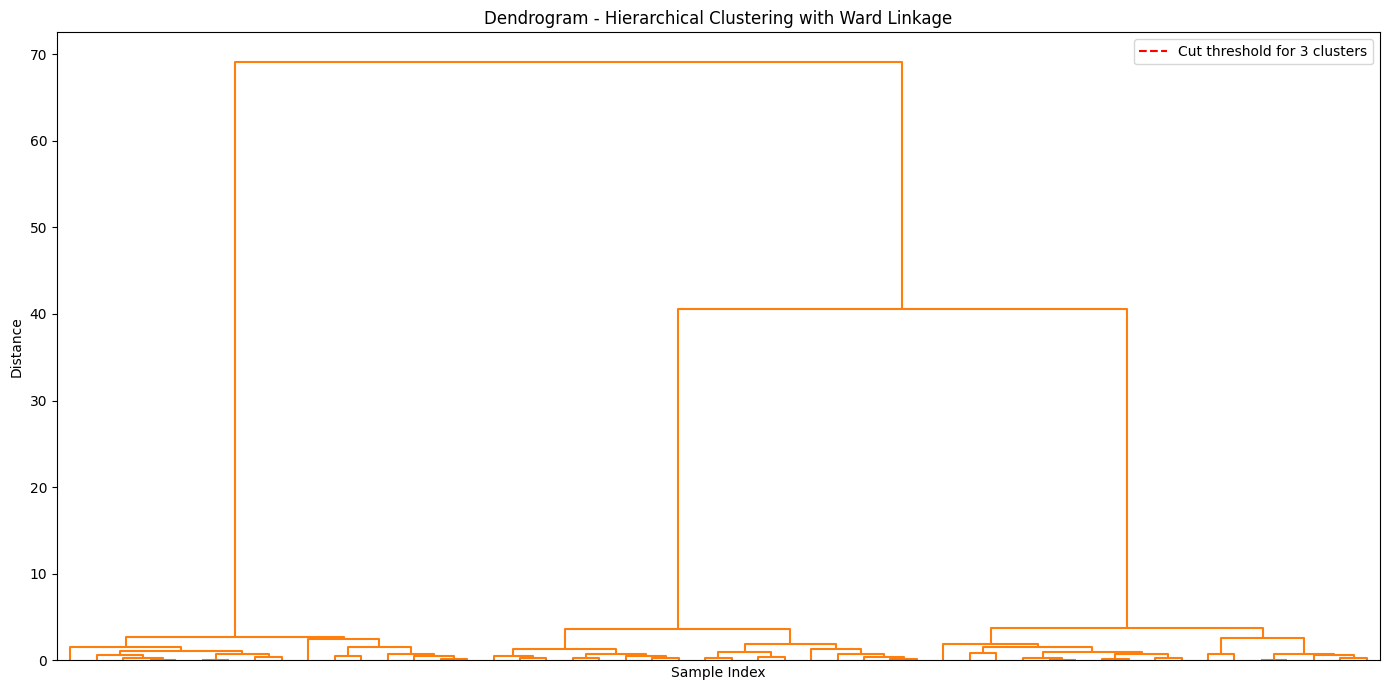


--- How to read the dendrogram ---
1. The height of each merge (y-axis) shows the distance between clusters
2. Horizontal lines represent merged clusters
3. The longer the vertical line, the more different the clusters being merged
4. Cut the tree at a height to determine the number of clusters


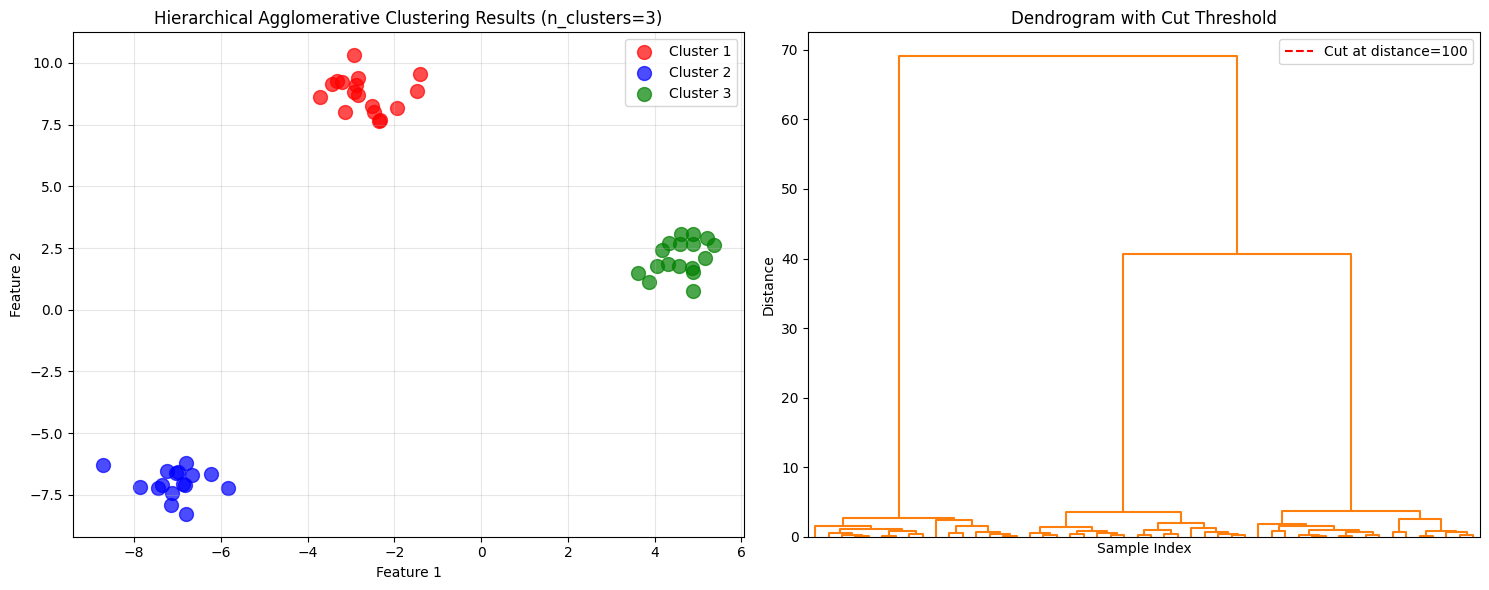

In [2]:
# Step 1: Create a linkage matrix (essential for dendrograms)
# The linkage matrix shows how clusters are merged together
Z = linkage(X, method='ward')  # Creates hierarchical clustering linkage
print("Linkage matrix shape:", Z.shape)
print("First 10 merges in the hierarchy:")
print(Z[:10])

# Step 2: Create dendrogram visualization
plt.figure(figsize=(14, 7))
dendrogram(Z, no_labels=True, color_threshold=100)  # color_threshold helps visualize cutting points
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.title('Dendrogram - Hierarchical Clustering with Ward Linkage')
plt.axhline(y=100, c='red', linestyle='--', label='Cut threshold for 3 clusters')
plt.legend()
plt.tight_layout()
plt.show()

print("\n--- How to read the dendrogram ---")
print("1. The height of each merge (y-axis) shows the distance between clusters")
print("2. Horizontal lines represent merged clusters")
print("3. The longer the vertical line, the more different the clusters being merged")
print("4. Cut the tree at a height to determine the number of clusters")

# Step 3: Apply Agglomerative Clustering with 3 clusters
agg_clustering = AgglomerativeClustering(
    n_clusters=3,  # Number of clusters to form
    linkage='ward'  
)
# Linkage methods: 
# - 'ward': minimizes the variance of the clusters being merged
# - 'complete': uses the maximum distance between points in the clusters
# - 'average': uses the average distance between points in the clusters
# - 'single': uses the minimum distance between points in the clusters
# Note: 'ward' is generally preferred for Euclidean distances and tends to create more compact clusters, while 'complete', 'average', and 'single' can be more sensitive to outliers and may produce different cluster shapes.
# why we need different linkage methods?
# Different linkage methods can capture different types of cluster structures and can be more or less sensitive to outliers. For example, 'ward' tends to create more compact clusters and is less sensitive to outliers, while 'complete' can create more elongated clusters and is more sensitive to outliers. Choosing the right linkage method depends on the specific characteristics of the dataset and the desired cluster shapes.

# Fit model and get cluster labels for each data point
cluster_labels = agg_clustering.fit_predict(X)

# Step 4: Create visualization of clusters
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Scatter plot of clusters
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i in range(3):
    cluster_points = X[cluster_labels == i]  # Get points in current cluster
    axes[0].scatter(cluster_points[:, 0], cluster_points[:, 1],
                c=colors[i], label=f'Cluster {i+1}', s=100, alpha=0.7)

axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_title('Hierarchical Agglomerative Clustering Results (n_clusters=3)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Dendrogram with cut line
dendrogram(Z, ax=axes[1], no_labels=True, color_threshold=100)
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Distance')
axes[1].set_title('Dendrogram with Cut Threshold')
axes[1].axhline(y=100, c='red', linestyle='--', label='Cut at distance=100')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Hierarchical Divisive Clustering (Top-Down)

**How it works:**
- Start with all data points in one cluster
- Recursively split clusters into smaller clusters
- Continue until each point is in its own cluster
- Creates the same dendrogram structure but in reverse order

**Advantages:**
- More intuitive for some problems (start with big picture)
- Can identify major groupings first

**Disadvantages:**
- Computationally expensive (more calculations at beginning)
- Less commonly used than Agglomerative

**Use cases:** Document hierarchies, taxonomy generation, organizational structures

**Note:** Divisive clustering is computationally expensive, so we mainly work with Agglomerative clustering. However, we can use Agglomerative with different linkage methods to explore different hierarchical structures.

SECTION A: Cluster Results for Different Linkage Methods


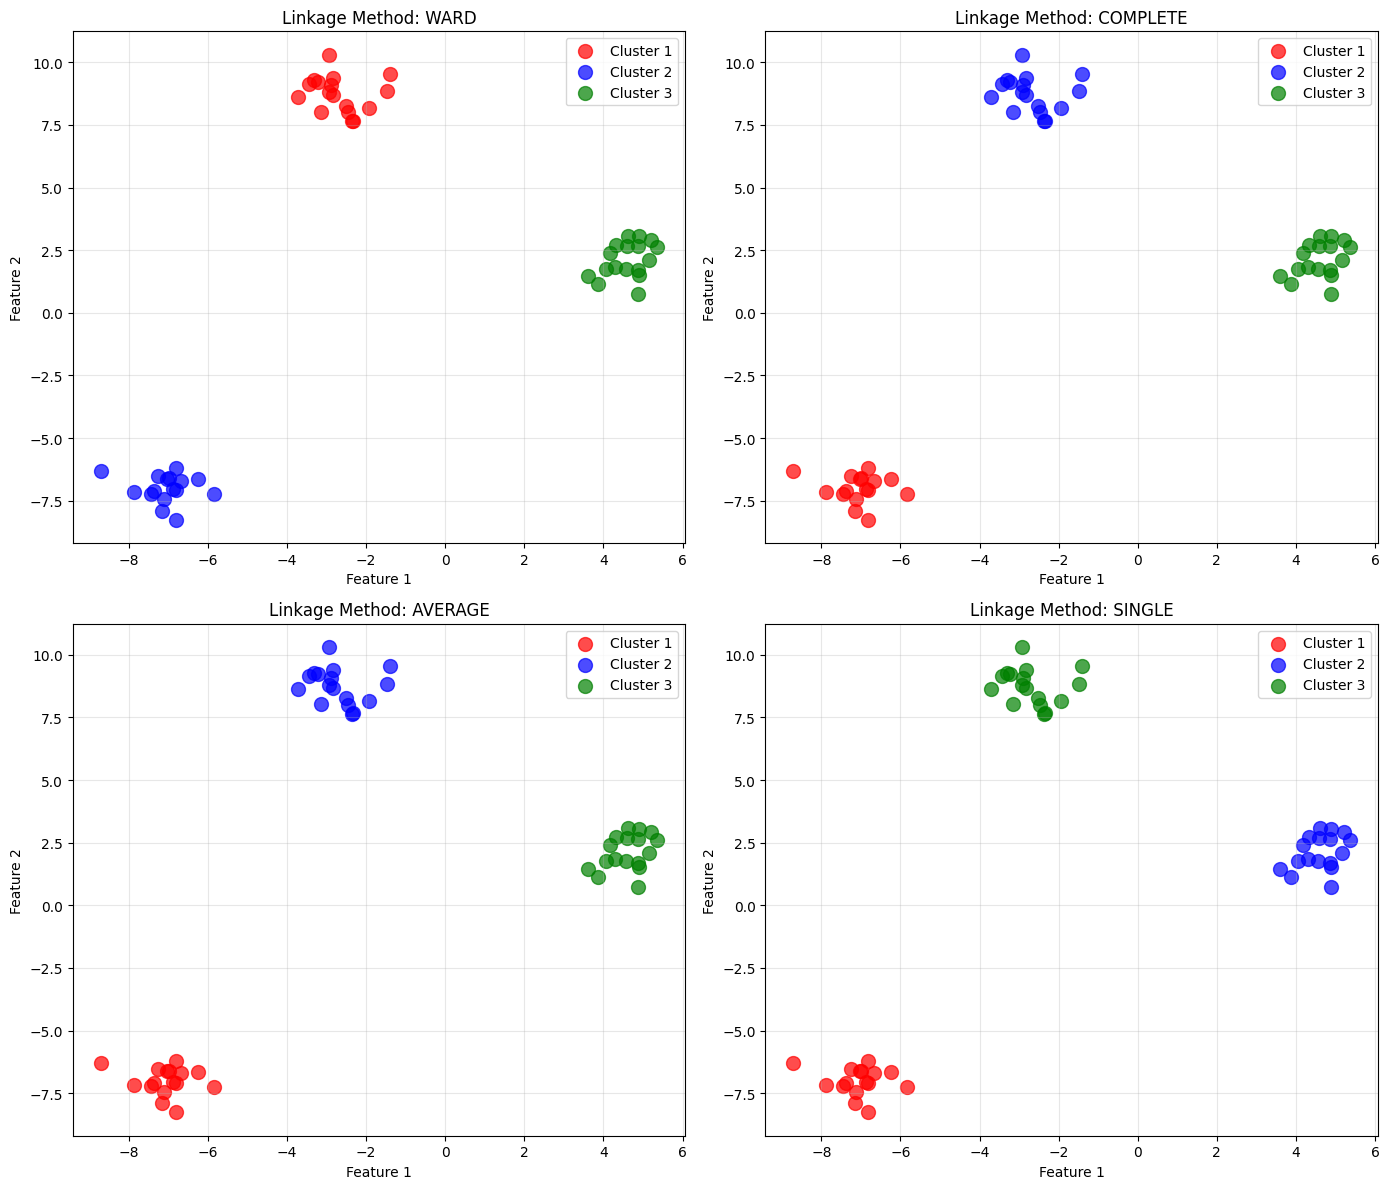


SECTION B: Dendrograms for Different Linkage Methods

Notice how different linkage methods create DIFFERENT hierarchical structures!
This is the KEY DIFFERENCE you'll see in the dendrograms below.



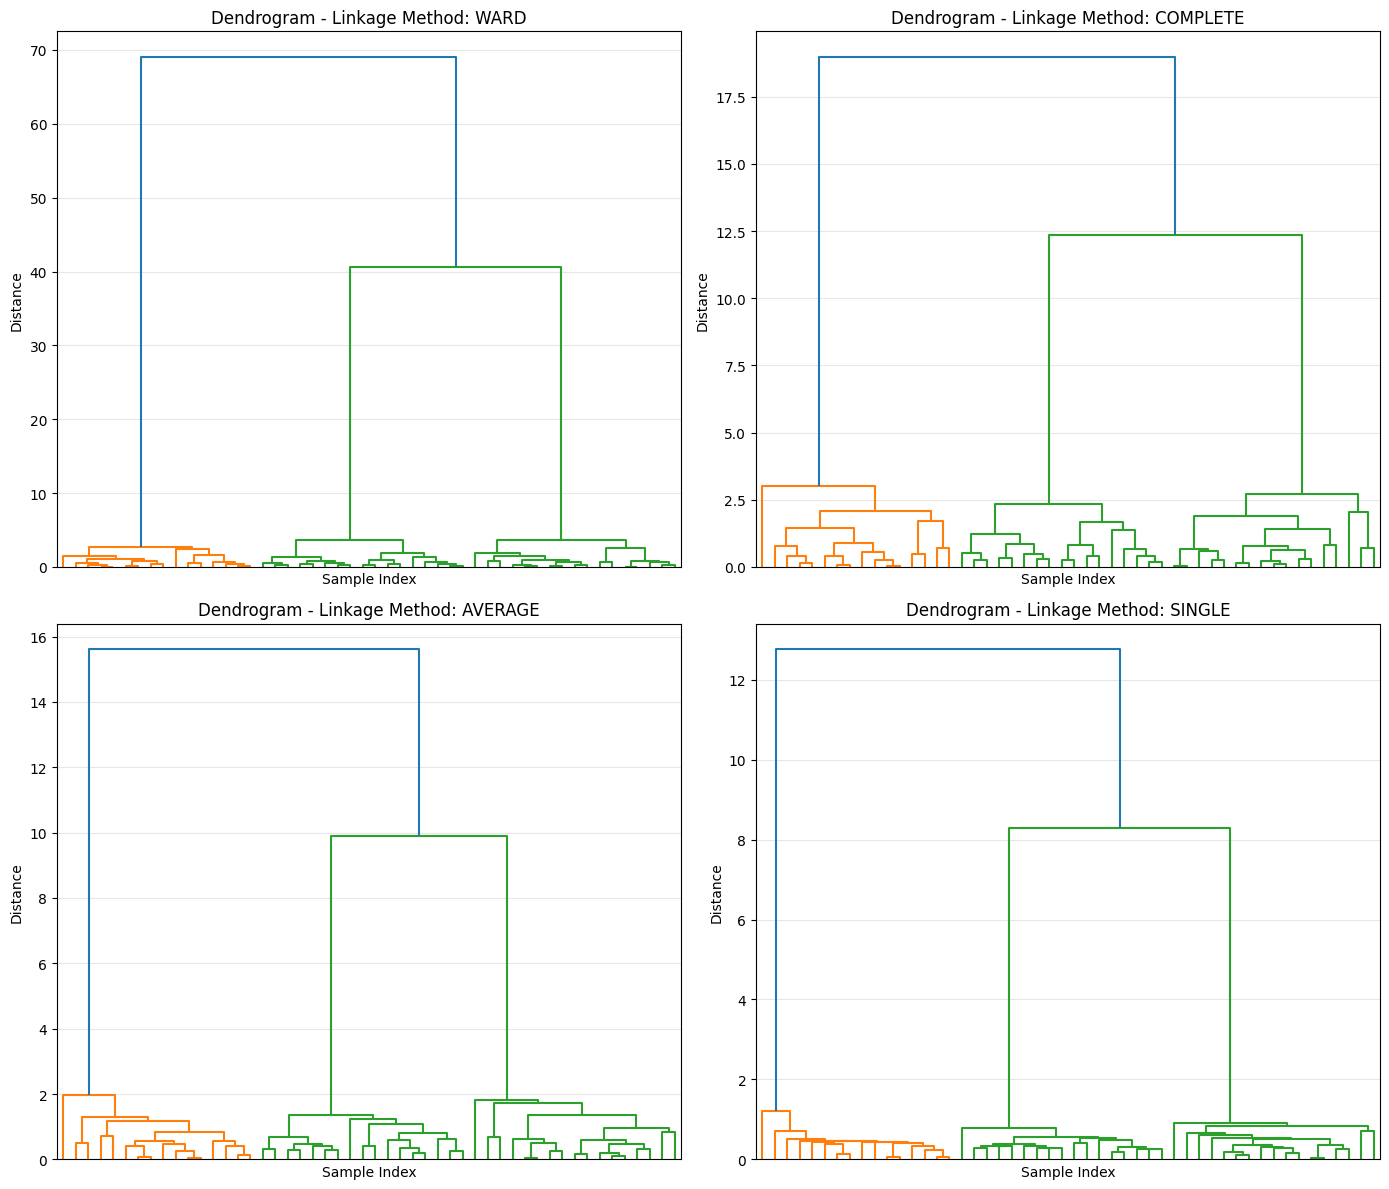


Key Observations:
1. Ward linkage creates more balanced, compact clusters (symmetric dendrogram)
2. Complete linkage is sensitive to outliers (can create elongated clusters)
3. Average linkage is a middle ground between Ward and Complete
4. Single linkage is prone to 'chaining' - connecting distant points through intermediates

Different linkage methods produce different clustering hierarchies!
- ward: minimizes variance (similar to divisive approach) - RECOMMENDED for most cases
- complete: minimizes maximum distance between clusters - BEST for compact, spherical clusters
- average: minimizes average distance between clusters - BALANCED approach
- single: minimizes minimum distance between clusters - PRONE TO CHAINING, rarely used


In [3]:
# Practical comparison: Different Linkage Methods in Agglomerative Clustering
# Different linkage methods behave like different approaches to hierarchical clustering

linkage_methods = ['ward', 'complete', 'average', 'single']

print("=" * 80)
print("SECTION A: Cluster Results for Different Linkage Methods")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):
    # Apply clustering with different linkage method
    clustering = AgglomerativeClustering(n_clusters=3, linkage=method)
    cluster_labels = clustering.fit_predict(X)
    
    # Plot results
    for i in range(3):
        cluster_points = X[cluster_labels == i]
        axes[idx].scatter(cluster_points[:, 0], cluster_points[:, 1], 
                         c=colors[i], label=f'Cluster {i+1}', s=100, alpha=0.7)
    
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')
    axes[idx].set_title(f'Linkage Method: {method.upper()}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("SECTION B: Dendrograms for Different Linkage Methods")
print("=" * 80)
print("\nNotice how different linkage methods create DIFFERENT hierarchical structures!")
print("This is the KEY DIFFERENCE you'll see in the dendrograms below.\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):
    # Create linkage matrix for this method
    Z_method = linkage(X, method=method)
    
    # Plot dendrogram
    dendrogram(Z_method, ax=axes[idx], no_labels=True, color_threshold=None)
    axes[idx].set_xlabel('Sample Index')
    axes[idx].set_ylabel('Distance')
    axes[idx].set_title(f'Dendrogram - Linkage Method: {method.upper()}')
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add horizontal line at distance=100 to show potential cut point
    axes[idx].axhline(y=100, c='red', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("1. Ward linkage creates more balanced, compact clusters (symmetric dendrogram)")
print("2. Complete linkage is sensitive to outliers (can create elongated clusters)")
print("3. Average linkage is a middle ground between Ward and Complete")
print("4. Single linkage is prone to 'chaining' - connecting distant points through intermediates")
print("\n" + "=" * 80)
print("Different linkage methods produce different clustering hierarchies!")
print("=" * 80)
print("- ward: minimizes variance (similar to divisive approach) - RECOMMENDED for most cases")
print("- complete: minimizes maximum distance between clusters - BEST for compact, spherical clusters")
print("- average: minimizes average distance between clusters - BALANCED approach")
print("- single: minimizes minimum distance between clusters - PRONE TO CHAINING, rarely used")

## Summary: Key Differences

| Aspect | Agglomerative (Bottom-Up) | Divisive (Top-Down) |
|--------|--------------------------|-------------------|
| Approach | Merge clusters | Split clusters |
| Complexity | Lower (practical) | Higher (expensive) |
| Dendrogram | Yes | Yes |
| Common Use | Very common | Rarely used |
| Sklearn Support | Yes (AgglomerativeClustering) | No (not practical for large data) |

## When to Use Hierarchical Clustering

✅ **Use when:**
- You need to visualize hierarchical relationships
- Number of clusters is unknown
- You want to explore different clustering levels
- Working with smaller datasets

❌ **Avoid when:**
- Working with very large datasets (computationally expensive)
- Need fast clustering (K-Means is faster)
- Clusters are non-spherical (DBSCAN might be better)